# Rule-Unexplained Failures — AI4I 2020 Predictive Maintenance

## Objective

Investigate failures that are **not covered by the documented HDF/PWF/OSF rules**.

We call these:

> **rule-unexplained failures**

We do not automatically call them unpredictable.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, recall_score

DATA_PATH = Path("../data/raw/ai4i2020.csv")
df = pd.read_csv(DATA_PATH)

TARGET = "Machine failure"
RANDOM_STATE = 42

# Derived variables
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_w"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
)

strain_limits = {"L": 11000, "M": 12000, "H": 13000}
df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
df["strain_limit"] = df["Type"].map(strain_limits)
df["strain_ratio"] = df["wear_torque"] / df["strain_limit"]

## 1. Recreate documented HDF/PWF/OSF rules

These are deterministic benchmark rules, not ML features.

In [2]:
df["rule_HDF"] = (
    (df["temp_diff"] < 8.6)
    & (df["Rotational speed [rpm]"] < 1380)
)

df["rule_PWF"] = (
    (df["power_w"] < 3500)
    | (df["power_w"] > 9000)
)

df["rule_OSF"] = (
    df["wear_torque"] > df["strain_limit"]
)

df["rule_any"] = (
    df["rule_HDF"]
    | df["rule_PWF"]
    | df["rule_OSF"]
)

df["rule_unexplained"] = (
    (df[TARGET] == 1)
    & (~df["rule_any"])
)

print("Total failures:", int(df[TARGET].sum()))
print("Rule-covered failures:", int(((df[TARGET] == 1) & df["rule_any"]).sum()))
print("Rule-unexplained failures:", int(df["rule_unexplained"].sum()))
print(
    "Rule-unexplained percentage:",
    round(df.loc[df[TARGET] == 1, "rule_unexplained"].mean() * 100, 2),
    "%"
)

Total failures: 339
Rule-covered failures: 287
Rule-unexplained failures: 52
Rule-unexplained percentage: 15.34 %


## 2. Failure-mode composition of rule-unexplained cases

This helps determine whether the residual group is associated with particular
failure-mode indicators.

In [3]:
mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

rule_unexplained_mode_counts = (
    df.loc[df["rule_unexplained"], mode_cols]
      .sum()
      .sort_values(ascending=False)
)

rule_unexplained_mode_counts

TWF    43
RNF     1
HDF     0
PWF     0
OSF     0
dtype: int64

In [4]:
mode_comparison = pd.DataFrame({
    "all_failures": df.loc[df[TARGET] == 1, mode_cols].sum(),
    "rule_unexplained_failures": df.loc[df["rule_unexplained"], mode_cols].sum()
})

mode_comparison["residual_share_percent"] = (
    mode_comparison["rule_unexplained_failures"]
    / mode_comparison["rule_unexplained_failures"].sum()
    * 100
)

mode_comparison

,all_failures,rule_unexplained_failures,residual_share_percent
TWF,46,43,97.727273
HDF,115,0,0.000000
PWF,95,0,0.000000
OSF,98,0,0.000000
RNF,1,1,2.272727


## 3. Compare sensor/derived distributions

Compare:
- normal observations
- rule-covered failures
- rule-unexplained failures

In [5]:
analysis_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

df["analysis_group"] = np.select(
    [
        df[TARGET].eq(0),
        df[TARGET].eq(1) & df["rule_any"],
        df["rule_unexplained"]
    ],
    [
        "Normal",
        "Rule-covered failure",
        "Rule-unexplained failure"
    ],
    default="Other"
)

group_summary = (
    df.groupby("analysis_group")[analysis_features]
      .agg(["count", "mean", "median", "std"])
)

group_summary

Air temperature [K]                                \
                                       count        mean  median       std   
analysis_group                                                               
Normal                                  9661  299.973999  300.00  1.990748   
Rule-covered failure                     287  300.991289  301.80  2.082082   
Rule-unexplained failure                  52  300.307692  300.45  1.929934   

                         Process temperature [K]                      \
                                           count        mean  median   
analysis_group                                                         
Normal                                      9661  309.995570  310.00   
Rule-covered failure                         287  310.314634  310.40   
Rule-unexplained failure                      52  310.155769  310.25   

                                   Rotational speed [rpm]               ...  \
                               std                  count         mean  ...   
analysis_group                                                          ...   
Normal                    1.486846                   9661  1540.260014  ...   
Rule-covered failure      1.352127                    287  1483.759582  ...   
Rule-unexplained failure  1.431907                     52  1566.730769  ...   

                              power_w              wear_torque               \
                               median          std       count         mean   
analysis_group                                                                
Normal                    6243.046225  1011.394393        9661  4213.842708   
Rule-covered failure      7880.999331  1873.435754         287  7172.225784   
Rule-unexplained failure  6021.176480   917.381378          52  7274.659615   

                                               strain_ratio            \
                           median          std        count      mean   
analysis_group                                                          
Normal                    3952.80  2709.744211         9661  0.367443   
Rule-covered failure      7752.00  4493.406609          287  0.636512   
Rule-unexplained failure  7647.15  2361.268081           52  0.631171   

                                              
                            median       std  
analysis_group                                
Normal                    0.345967  0.237478  
Rule-covered failure      0.680800  0.402646  
Rule-unexplained failure  0.632337  0.206765  

[3 rows x 36 columns]

## 4. Visualize useful comparisons

These plots are descriptive. Extreme small bins should not be treated as strong
evidence by themselves.

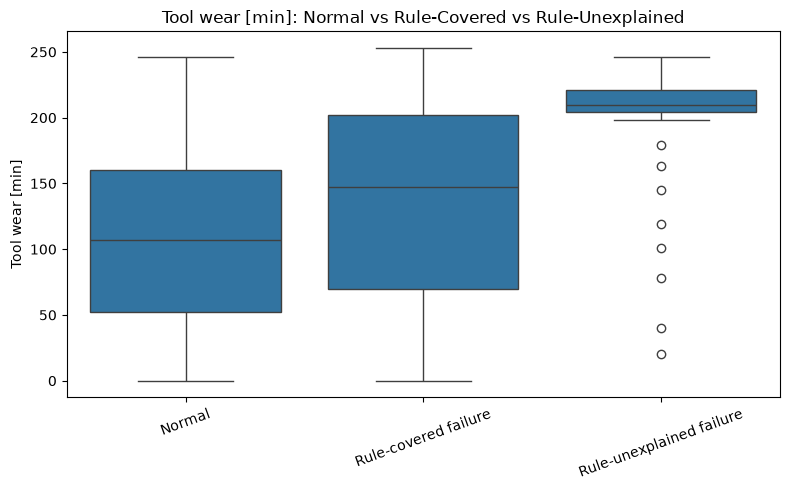

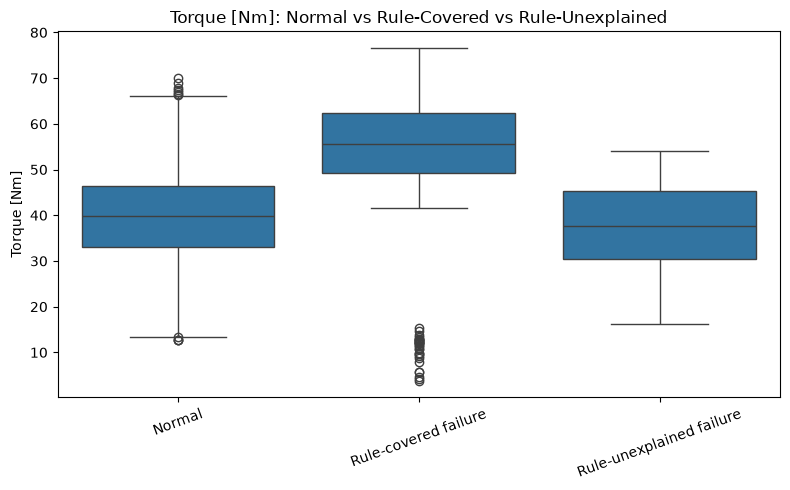

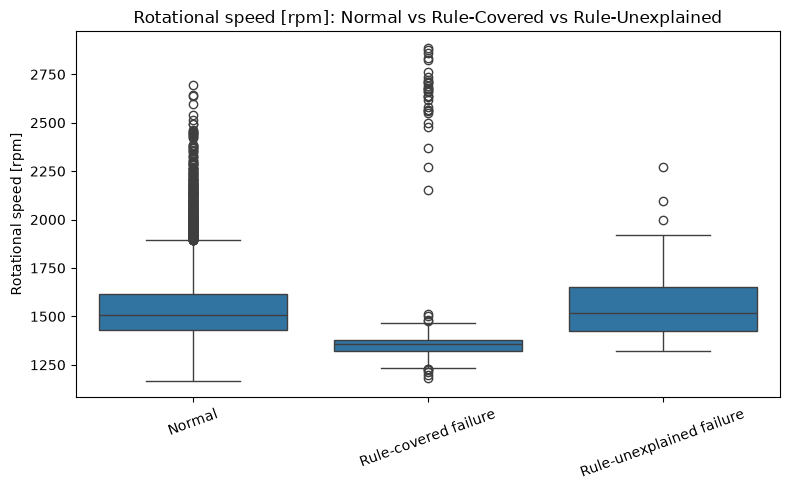

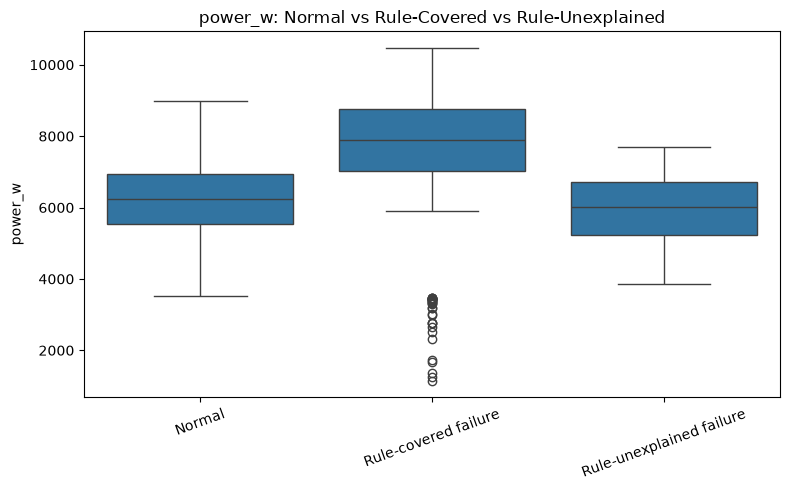

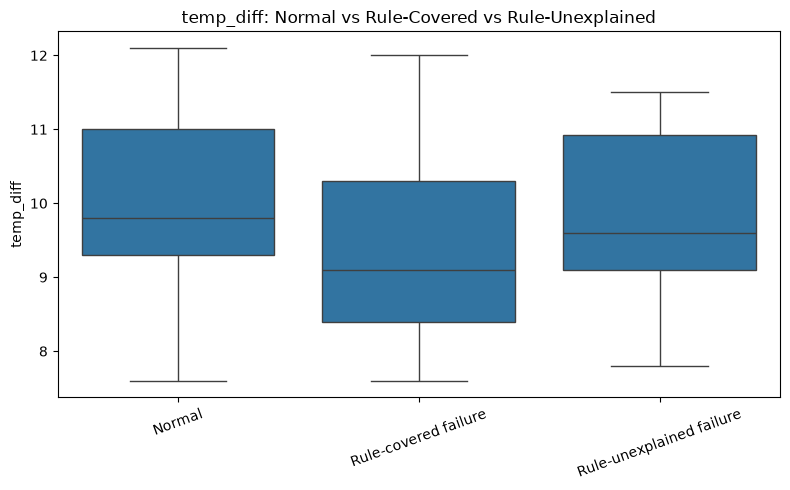

In [6]:
for feature in [
    "Tool wear [min]",
    "Torque [Nm]",
    "Rotational speed [rpm]",
    "power_w",
    "temp_diff"
]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df[df["analysis_group"].isin(
            ["Normal", "Rule-covered failure", "Rule-unexplained failure"]
        )],
        x="analysis_group",
        y=feature
    )
    plt.title(f"{feature}: Normal vs Rule-Covered vs Rule-Unexplained")
    plt.xlabel("")
    plt.ylabel(feature)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 5. Show the individual rule-unexplained cases

In [7]:
residual_cols = [
    "UDI", "Product ID", "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff", "power_w", "wear_torque", "strain_ratio",
    TARGET,
    *mode_cols
]

rule_unexplained_cases = (
    df.loc[df["rule_unexplained"], residual_cols]
      .sort_values("UDI")
)

print("Number of rule-unexplained cases:", len(rule_unexplained_cases))
display(rule_unexplained_cases)

Number of rule-unexplained cases: 52


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff,power_w,wear_torque,strain_ratio,Machine failure,TWF,HDF,PWF,OSF,RNF
77,78,L47257,L,298.8,308.9,1455,41.3,208,10.1,6292.767165,8590.4,0.780945,1,1,0,0,0,0
1087,1088,H30501,H,296.9,307.8,1549,35.8,206,10.9,5807.150244,7374.8,0.567292,1,1,0,0,0,0
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,11.1,6811.266088,1808.0,0.139077,1,0,0,0,0,0
1509,1510,L48689,L,298.0,308.5,1429,37.7,220,10.5,5641.598783,8294.0,0.754000,1,1,0,0,0,0
1682,1683,H31096,H,297.9,307.4,1604,36.1,225,9.5,6063.734588,8122.5,0.624808,1,1,0,0,0,0
1763,1764,L48943,L,298.2,307.6,1511,31.0,209,9.4,4905.178050,6479.0,0.589000,1,1,0,0,0,0
1996,1997,M16856,M,298.4,308.0,1416,38.2,198,9.6,5664.417218,7563.6,0.630300,1,1,0,0,0,0
2166,2167,M17026,M,299.6,309.2,1867,23.4,225,9.6,4574.975718,5265.0,0.438750,1,1,0,0,0,0
2244,2245,M17104,M,299.3,308.4,1542,37.5,203,9.1,6055.419840,7612.5,0.634375,1,1,0,0,0,0
2671,2672,M17531,M,299.7,309.3,1399,41.9,221,9.6,6138.473078,9259.9,0.771658,1,1,0,0,0,0


## 6. Test whether leakage-safe ML detects residual failures

Use out-of-fold probabilities so that a case is evaluated by a model that did not
train on that case.

This is a detection experiment, not evidence that the model has discovered a new
physical failure mechanism.

In [8]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

X = df[feature_columns]
y = df[TARGET].astype(int)

preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Type"]),
        ("num", "passthrough", [c for c in feature_columns if c != "Type"])
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof = np.zeros(len(df), dtype=float)

for train_idx, test_idx in cv.split(X, y):
    m = clone(model)
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

df["ml_oof_risk"] = oof

## 7. Residual failure detection at several thresholds

Because a 0.50 threshold is arbitrary, inspect multiple operating points instead of
claiming one threshold is universally correct.

In [9]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

residual_rows = []

residual_mask = df["rule_unexplained"]

for threshold in thresholds:
    detected = df.loc[residual_mask, "ml_oof_risk"] >= threshold

    residual_rows.append({
        "threshold": threshold,
        "rule_unexplained_count": int(residual_mask.sum()),
        "detected_by_ml": int(detected.sum()),
        "detected_percent": float(detected.mean() * 100)
    })

residual_detection = pd.DataFrame(residual_rows)

residual_detection

,threshold,rule_unexplained_count,detected_by_ml,detected_percent
0,0.3,52,1,1.923077
1,0.4,52,0,0.000000
2,0.5,52,0,0.000000
3,0.6,52,0,0.000000
4,0.7,52,0,0.000000


## 8. Compare OOF risk distributions

If rule-unexplained failures receive higher OOF risk than normal observations, that
is evidence that the residual group contains some learnable statistical signal.
It does not identify a causal mechanism.

In [10]:
risk_summary = (
    df.groupby("analysis_group")["ml_oof_risk"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

risk_summary

,count,mean,median,std,min,max
analysis_group,,,,,,
Normal,9661,0.013614,0.000000,0.045214,0.000000,0.875187
Rule-covered failure,287,0.823985,0.862425,0.138181,0.374767,0.996132
Rule-unexplained failure,52,0.073891,0.058347,0.069852,0.000000,0.308352


## Conclusion

The final conclusion must be based on the computed residual analysis.

Allowed conclusions include:
- the residual group contains detectable statistical signal;
- the residual group is weakly detected by the tested model;
- evidence is insufficient to determine whether the residual group is intrinsically unpredictable.

Do not call rule-unexplained failures "provably unpredictable" without substantially
stronger evidence.